<a href="https://colab.research.google.com/github/anishkr-sahu/revision_ml/blob/main/gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#libraries
import torch
import torch.nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
# check gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Hyper-parameter
latent_size= 100
hidden_size= 256
image_size= 28*28
batch_size= 100
num_epochs= 50
lr= 0.0001

In [5]:
# data set
transform= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])
# define dataset
dataset= torchvision.datasets.MNIST(root='./data',train=True, transform=transform,download=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.84MB/s]


In [6]:
# dataloader
data_loader= torch.utils.data.DataLoader(dataset=dataset, batch_size=batch_size,shuffle=True)

In [7]:
# Define Generator
class Generator(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.model = torch.nn.Sequential(
        torch.nn.Linear(latent_size, hidden_size),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden_size, image_size),
        torch.nn.Tanh()
    )

  def forward(self,x):
    return self.model(x)

In [8]:
# Define Discriminator
class Discriminator(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.model = torch.nn.Sequential(
        torch.nn.Linear(image_size, hidden_size),
        torch.nn.LeakyReLU(0.2),
        torch.nn.Linear(hidden_size, 1),
        torch.nn.Sigmoid()
    )

  def forward(self,x):
    return self.model(x)

In [9]:
# initializing
G = Generator().to(device)
D = Discriminator().to(device)

In [10]:
# Loss function

criteria = torch.nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(),lr=lr)
d_optimizer = torch.optim.Adam(D.parameters(),lr=lr)

In [11]:
# Training the GAN
total_step = len(data_loader)
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)

        # Create the labels which are later used as input for the BCE loss
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ================================================================== #
        #                      Train the Discriminator                       #
        # ================================================================== #

        # Compute BCE_Loss for real images
        outputs = D(images)
        d_loss_real = criteria(outputs, real_labels)
        real_score = outputs

        # Compute BCE_Loss for fake images
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)
        d_loss_fake = criteria(outputs, fake_labels)
        fake_score = outputs

        # Backprop and optimize Discriminator
        d_loss = d_loss_real + d_loss_fake
        d_optimizer.zero_grad()
        g_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # ================================================================== #
        #                        Train the Generator                         #
        # ================================================================== #

        # Compute loss with fake images
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)
        g_loss = criteria(outputs, real_labels)

        # Backprop and optimize Generator
        d_optimizer.zero_grad()
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}'
                  .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(),
                          real_score.mean().item(), fake_score.mean().item()))


Epoch [0/50], Step [200/600], d_loss: 0.8979, g_loss: 0.7695, D(x): 0.84, D(G(z)): 0.51
Epoch [0/50], Step [400/600], d_loss: 0.5620, g_loss: 1.2116, D(x): 0.86, D(G(z)): 0.33
Epoch [0/50], Step [600/600], d_loss: 1.0046, g_loss: 0.7338, D(x): 0.74, D(G(z)): 0.50
Epoch [1/50], Step [200/600], d_loss: 1.1762, g_loss: 0.6945, D(x): 0.66, D(G(z)): 0.53
Epoch [1/50], Step [400/600], d_loss: 0.8913, g_loss: 0.9689, D(x): 0.71, D(G(z)): 0.41
Epoch [1/50], Step [600/600], d_loss: 1.1042, g_loss: 0.8405, D(x): 0.64, D(G(z)): 0.47
Epoch [2/50], Step [200/600], d_loss: 0.9104, g_loss: 0.9837, D(x): 0.70, D(G(z)): 0.42
Epoch [2/50], Step [400/600], d_loss: 0.6820, g_loss: 1.2432, D(x): 0.74, D(G(z)): 0.31
Epoch [2/50], Step [600/600], d_loss: 0.8751, g_loss: 0.9950, D(x): 0.70, D(G(z)): 0.39
Epoch [3/50], Step [200/600], d_loss: 0.9400, g_loss: 1.0119, D(x): 0.65, D(G(z)): 0.39
Epoch [3/50], Step [400/600], d_loss: 0.9780, g_loss: 1.0038, D(x): 0.64, D(G(z)): 0.39
Epoch [3/50], Step [600/600], d_

In [12]:
# Save real images
sample_dir = 'samples'
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)

# Save the model checkpoints
torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')


## Visualize Generated Images

Generated images saved to samples/fake_images.png


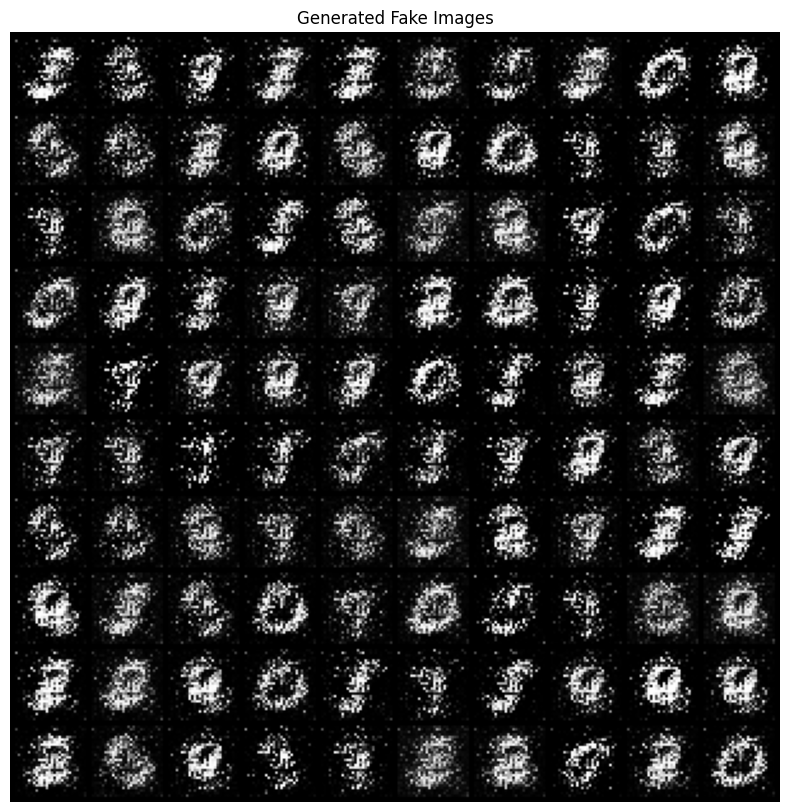

In [13]:
import torchvision.utils as vutils

# Load the trained generator
G.load_state_dict(torch.load('G.ckpt'))
G.eval() # Set generator to evaluation mode

# Generate a batch of fake images
with torch.no_grad():
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z).reshape(-1, 1, 28, 28) # Reshape for display

# Save the generated images to a file for later viewing
vutils.save_image(fake_images.cpu(), os.path.join(sample_dir, 'fake_images.png'), normalize=True, nrow=10)
print(f"Generated images saved to {os.path.join(sample_dir, 'fake_images.png')}")

# Display a few generated images
plt.figure(figsize=(10, 10))
plt.imshow(vutils.make_grid(fake_images.cpu(), nrow=10, normalize=True).permute(1, 2, 0))
plt.axis('off')
plt.title('Generated Fake Images')
plt.show()